<a href="https://colab.research.google.com/github/manuelapop/health_classification_dataset_model_train/blob/main/health_classification_good.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score


from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report, mean_squared_error
)

import seaborn as sns
plt.style.use("ggplot")
sns.set_theme()

import sys
import keras
import sklearn
import warnings

warnings.filterwarnings('ignore')

print(f'Python version: {sys.version}')
print(f'Keras version: {keras.__version__}')
print(f'sklearn version: {sklearn.__version__}')
print(f'np version: {np.__version__}')
print(f'pd version: {pd.__version__}')

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Keras version: 3.10.0
sklearn version: 1.6.1
np version: 2.0.2
pd version: 2.2.2


In [3]:
data_path = './health_lifestyle_classification.csv' # change this if necessary

df = pd.read_csv(data_path)

print(df.shape)
df.head()
df.info()

(100000, 48)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000

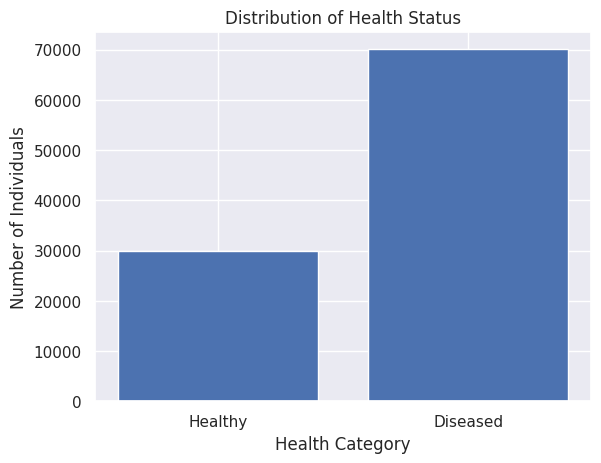

In [4]:
counts = df['target'].value_counts().sort_index()

# Plot as a bar chart
plt.bar(['Healthy', 'Diseased'], counts)
plt.title('Distribution of Health Status')
plt.ylabel('Number of Individuals')
plt.xlabel('Health Category')
# Save the plot as PNG file
filename = f"healh_status_distribution.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Drop non-informative ID column
df = df.drop(columns=['survey_code'])
# Make sure labels are numeric
y = df['target'].map({'healthy': 0, 'diseased': 1}).astype('int32')

# Rebuild X from scratch
X = df.drop(columns=['target'])

# Split first (so we fit scalers on train only)
from sklearn.model_selection import train_test_split
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:

#if you run the RNN
# Numeric/categorical split
num_cols = X_train_df.select_dtypes(include=['float64','int64','int32','float32']).columns
cat_cols = X_train_df.select_dtypes(include=['object']).columns

# Impute
X_train_df[num_cols] = X_train_df[num_cols].fillna(X_train_df[num_cols].median())
X_test_df[num_cols]  = X_test_df[num_cols].fillna(X_train_df[num_cols].median())

X_train_df[cat_cols] = X_train_df[cat_cols].fillna('Unknown')
X_test_df[cat_cols]  = X_test_df[cat_cols].fillna('Unknown')

# One-hot encode categoricals
import pandas as pd
X_train_df = pd.get_dummies(X_train_df, columns=cat_cols, drop_first=True)
X_test_df  = pd.get_dummies(X_test_df,  columns=cat_cols, drop_first=True)

# Align columns (important when train/test OHE produce different columns)
X_train_df, X_test_df = X_train_df.align(X_test_df, join='left', axis=1, fill_value=0)

# Scale numeric-like data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_test  = scaler.transform(X_test_df.values)

# Convert to proper numpy dtypes and RNN shape
X_train = np.asarray(X_train, dtype='float32')[:, None, :]  # (samples, 1, features)
X_test  = np.asarray(X_test,  dtype='float32')[:, None, :]
y_train = np.asarray(y_train, dtype='float32')              # (samples,)
y_test  = np.asarray(y_test,  dtype='float32')


In [11]:
model = Sequential([
    Input(shape=(1, X_train.shape[2])),
    SimpleRNN(8, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=20, batch_size=256,
    validation_split=0.2,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.3f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777 (3.04 KB)

 Trainable params: 777 (3.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6516 - loss: 0.6402 - val_accuracy: 0.7000 - val_loss: 0.6117
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7036 - loss: 0.6083 - val_accuracy: 0.7000 - val_loss: 0.6116
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7009 - loss: 0.6104 - val_accuracy: 0.7000 - val_loss: 0.6116
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6973 - loss: 0.6131 - val_accuracy: 0.7000 - val_loss: 0.6122
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7023 - loss: 0.6090 - val_accuracy: 0.7000 - val_loss: 0.6113
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7016 - loss: 0.6091 - val_accuracy: 0.7000 - val_loss: 0.6113
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7021 - loss: 0.6088 - val_accuracy: 0.7000 - val_loss: 0.6113
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7017 - loss: 0.6089 - val_accuracy: 0.

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
== Train ==
Accuracy : 0.700975
F1 Score : 0.0
Precision: 0.0
Recall   : 0.0
AUC      : 0.5350701349878206

== Test ==
Accuracy : 0.70095
F1 Score : 0.0
Precision: 0.0
Recall   : 0.0
AUC      : 0.49783466771199125

Classification Report (Test):
              precision    recall  f1-score   support

     Healthy      0.701     1.000     0.824     14019
    Diseased      0.000     0.000     0.000      5981

    accuracy                          0.701     20000
   macro avg      0.350     0.500     0.412     20000
weighted avg      0.491     0.701     0.578     20000



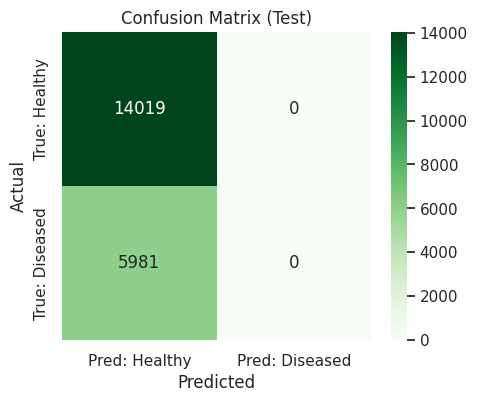

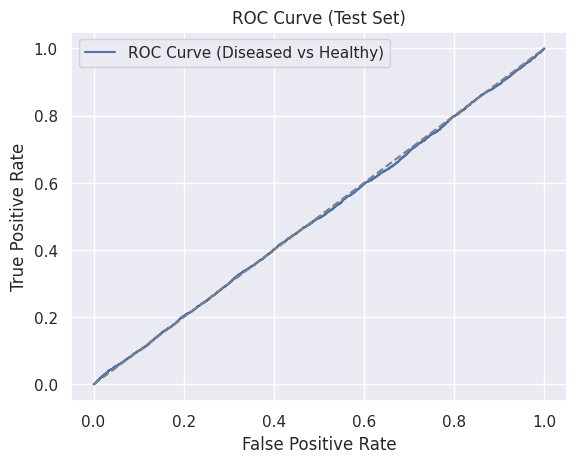

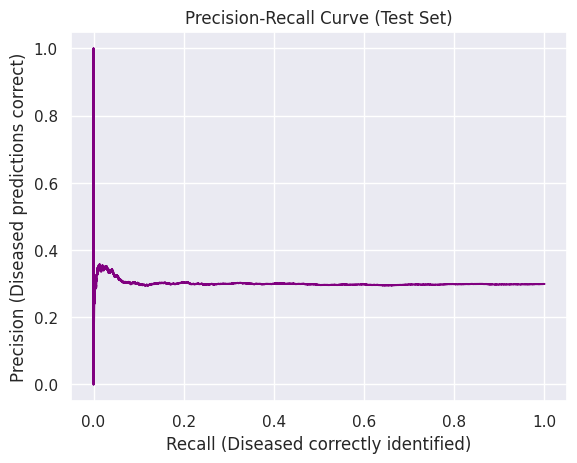

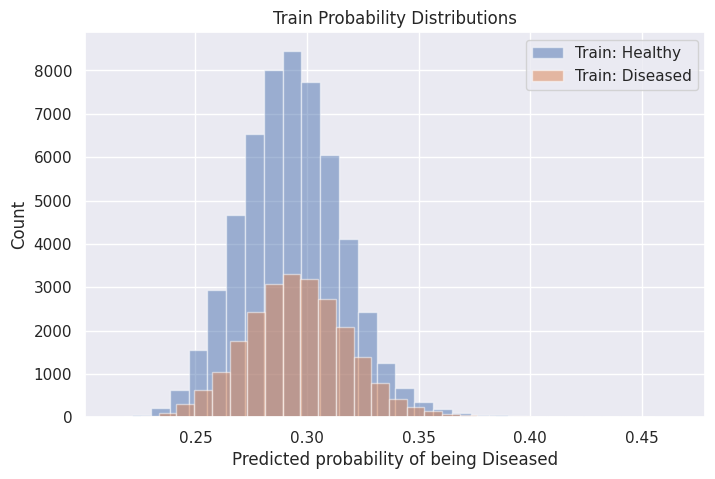

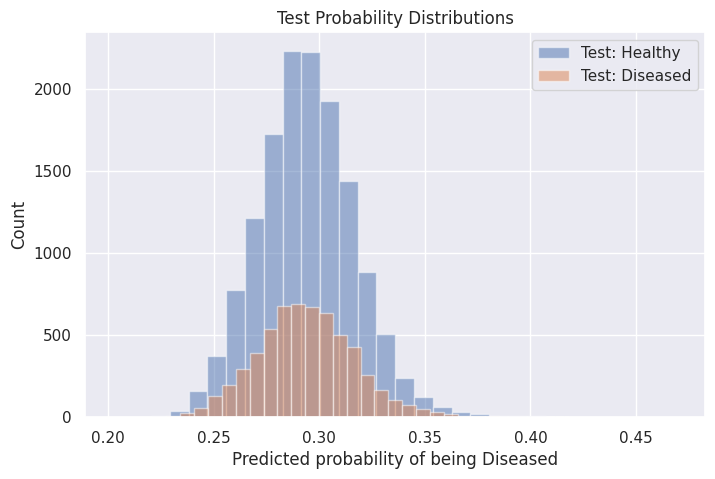


Best test accuracy: 0.701 at threshold=0.475 (F1=0.000)


In [12]:

# 1) Predict probabilities (sigmoid outputs in [0,1])
train_proba = model.predict(X_train).ravel()
test_proba  = model.predict(X_test).ravel()

# 2) Convert to class labels with a threshold (default 0.5)
thr = 0.5
train_pred = (train_proba >= thr).astype(int)
test_pred  = (test_proba  >= thr).astype(int)

# 3) Metrics
print("== Train ==")
print("Accuracy :", accuracy_score(y_train, train_pred))
print("F1 Score :", f1_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred))
print("Recall   :", recall_score(y_train, train_pred))
print("AUC      :", roc_auc_score(y_train, train_proba))

print("\n== Test ==")
print("Accuracy :", accuracy_score(y_test, test_pred))
print("F1 Score :", f1_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("AUC      :", roc_auc_score(y_test, test_proba))

print("\nClassification Report (Test):")
target_names = ['Healthy', 'Diseased']
print(classification_report(y_test, test_pred, target_names=target_names, digits=3))

# 4) Confusion matrix (test)
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred: Healthy', 'Pred: Diseased'],
            yticklabels=['True: Healthy', 'True: Diseased'])
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
# Save the plot as PNG file
filename = f"Confusion_Matrix.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

# 5) ROC curve (test)
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (Diseased vs Healthy)")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
# Save the plot as PNG file
filename = f"false_true.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

# 6) Precision-Recall curve (test)
prec, rec, _ = precision_recall_curve(y_test, test_proba)
plt.figure()
plt.plot(rec, prec, color='purple')
plt.xlabel("Recall (Diseased correctly identified)")
plt.ylabel("Precision (Diseased predictions correct)")
plt.title("Precision-Recall Curve (Test Set)")
# Save the plot as PNG file
filename = f"recall_diseased_predictions.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

# 7) Probability histograms (confidence visualization)
plt.figure(figsize=(8,5))
plt.hist(train_proba[y_train == 0], bins=30, alpha=0.5, label="Train: Healthy")
plt.hist(train_proba[y_train == 1], bins=30, alpha=0.5, label="Train: Diseased")
plt.xlabel("Predicted probability of being Diseased")
plt.ylabel("Count")
plt.title("Train Probability Distributions")
plt.legend()
# Save the plot as PNG file
filename = f"predicted_probability_train.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(test_proba[y_test == 0], bins=30, alpha=0.5, label="Test: Healthy")
plt.hist(test_proba[y_test == 1], bins=30, alpha=0.5, label="Test: Diseased")
plt.xlabel("Predicted probability of being Diseased")
plt.ylabel("Count")
plt.title("Test Probability Distributions")
plt.legend()
# Save the plot as PNG file
filename = f"predicted_probability_test.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

# 8) Optional: find best threshold for accuracy
best = (0, 0, 0)
for thr_try in np.linspace(0.2, 0.8, 25):
    pred_try = (test_proba >= thr_try).astype(int)
    acc_try = accuracy_score(y_test, pred_try)
    f1_try  = f1_score(y_test, pred_try)
    if acc_try > best[0]:
        best = (acc_try, thr_try, f1_try)

print(f"\nBest test accuracy: {best[0]:.3f} at threshold={best[1]:.3f} (F1={best[2]:.3f})")



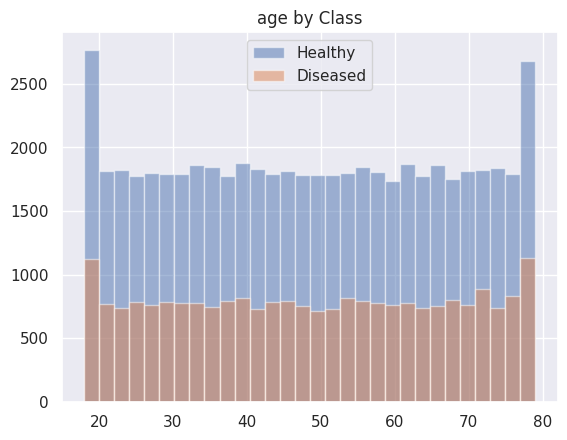

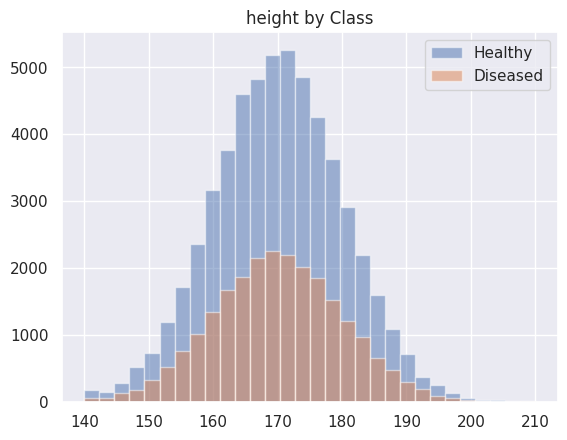

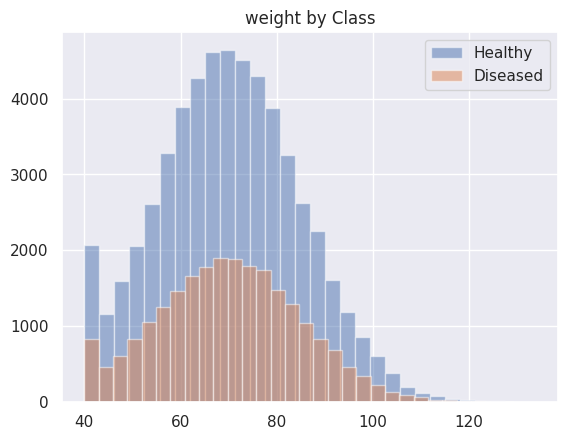

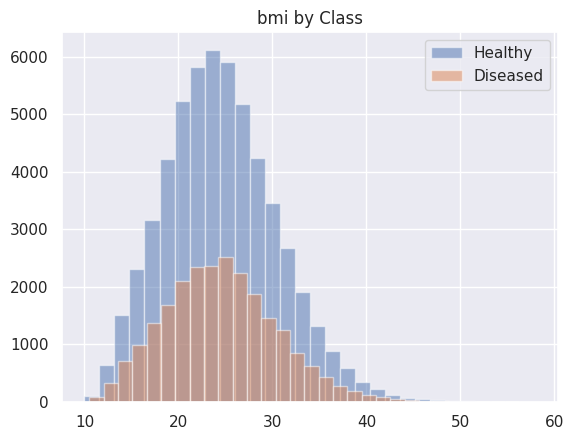

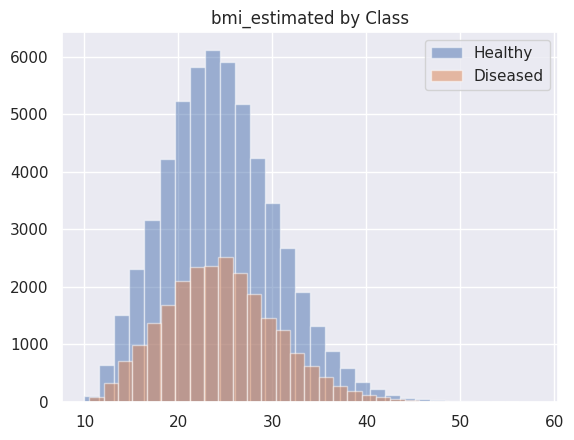

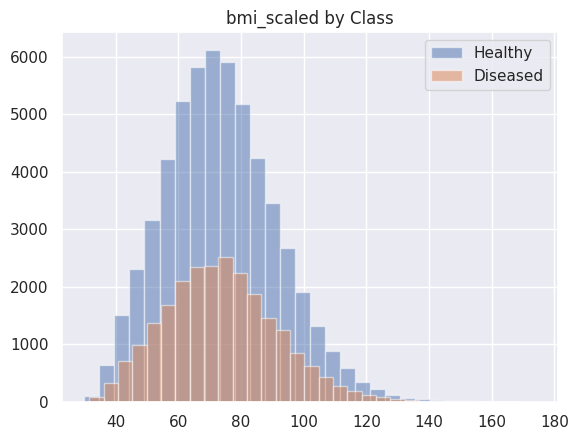

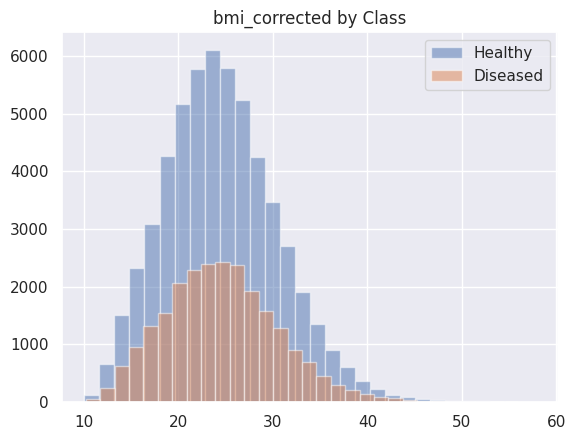

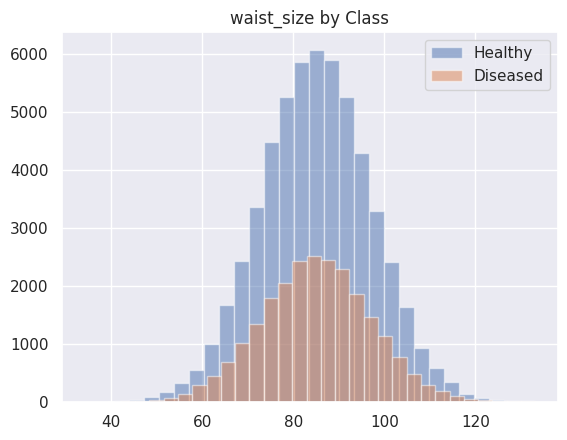

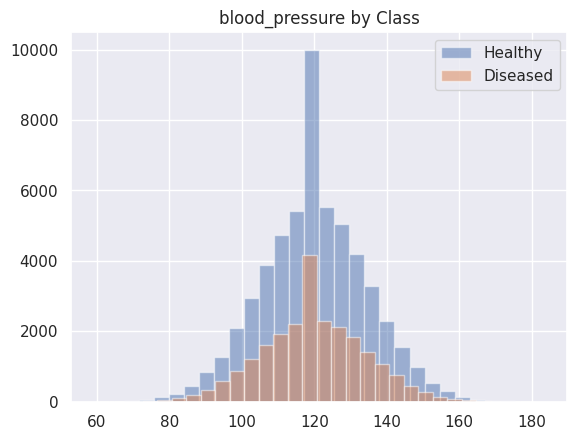

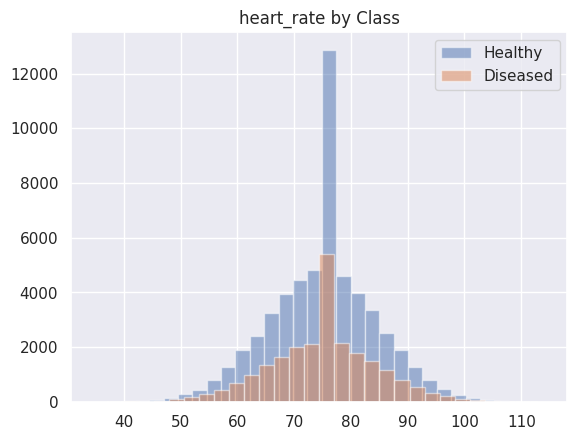

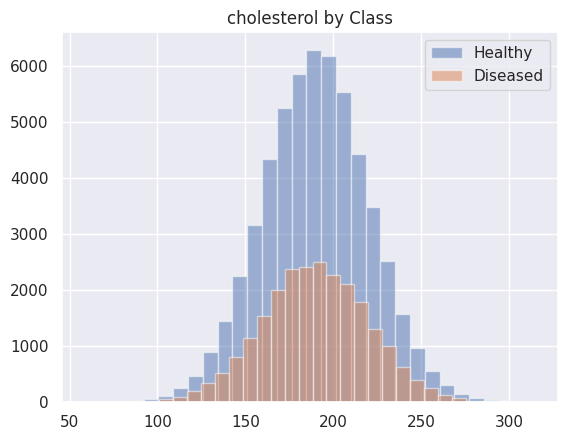

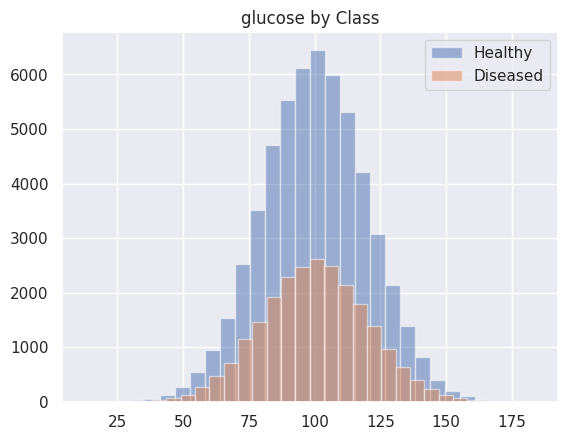

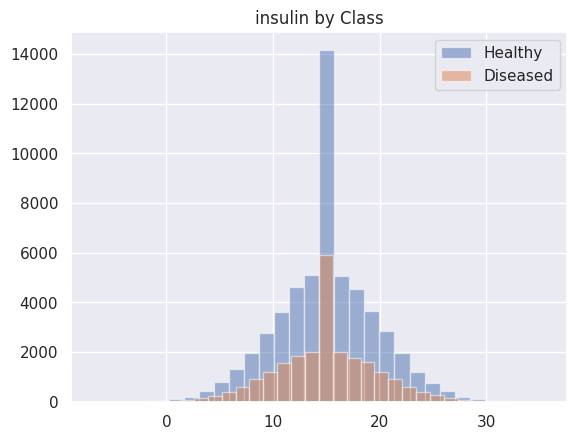

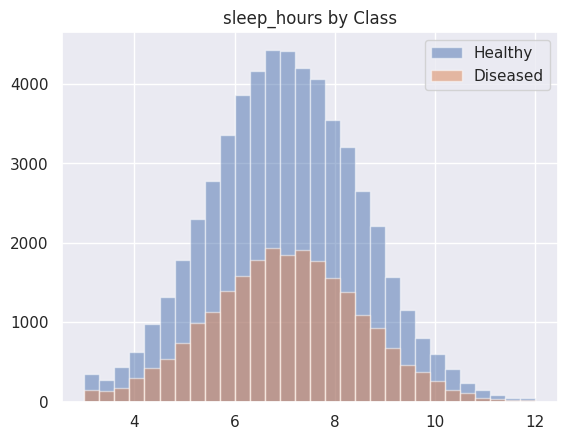

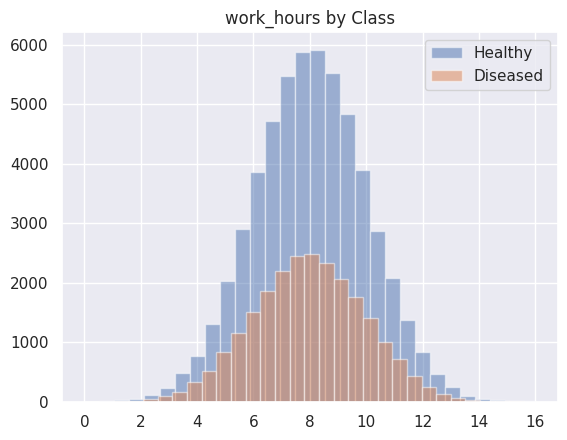

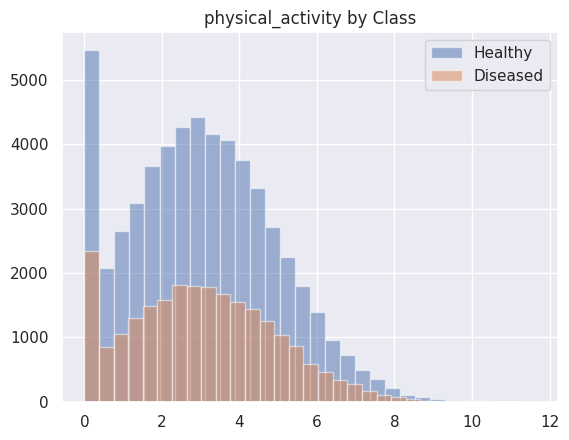

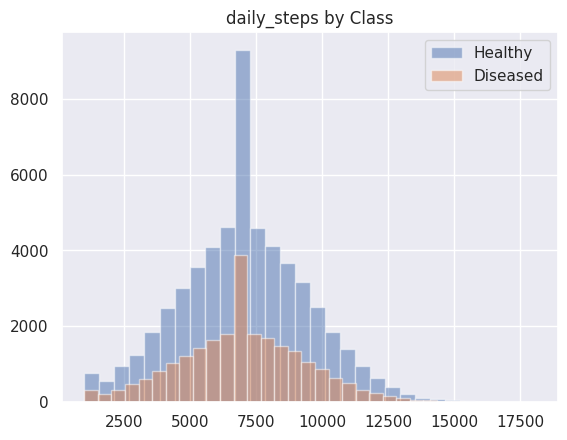

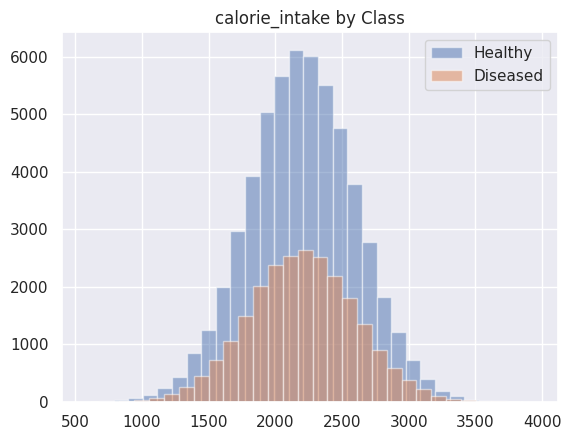

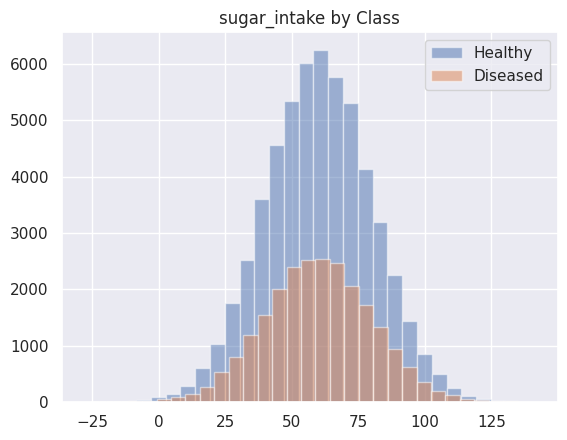

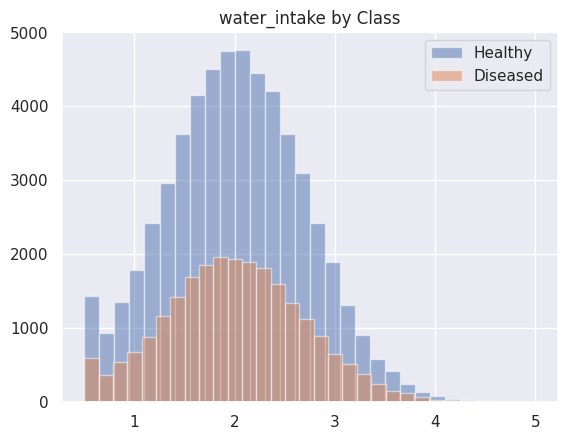

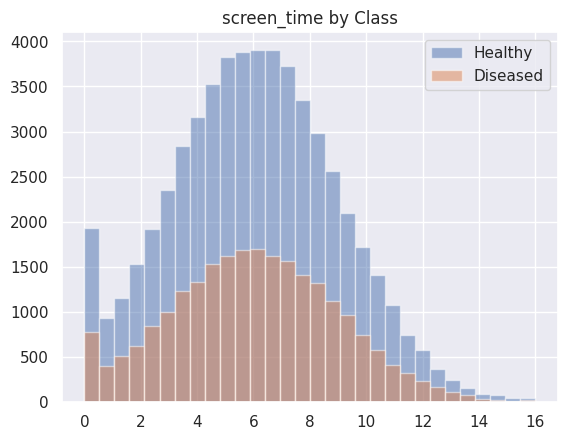

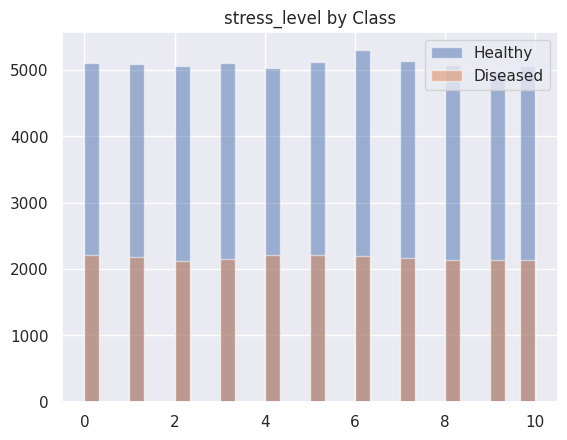

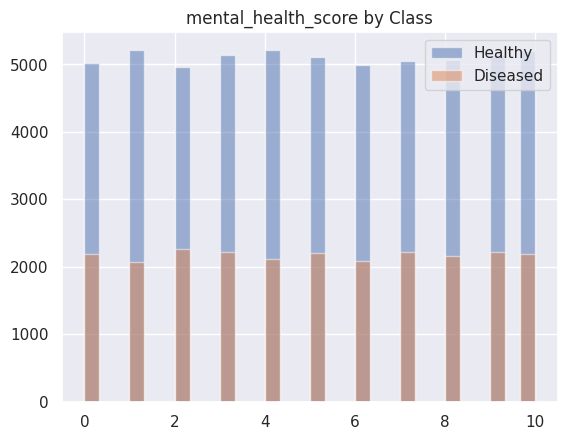

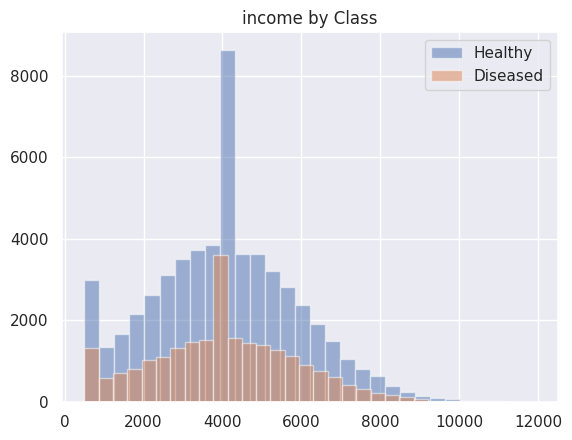

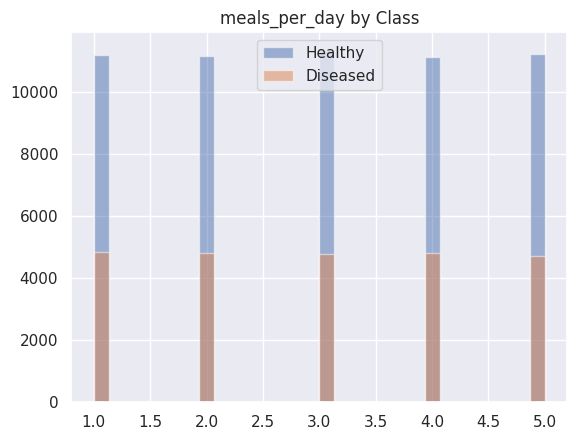

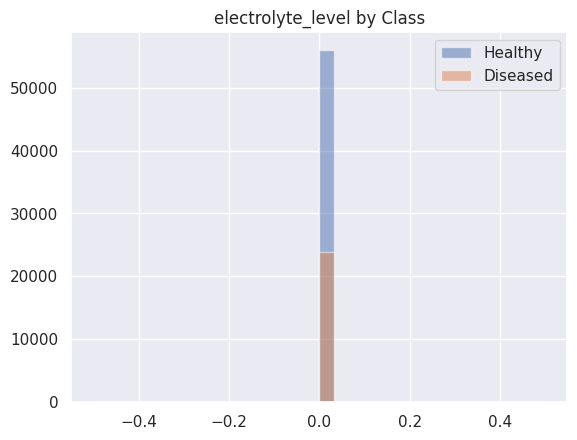

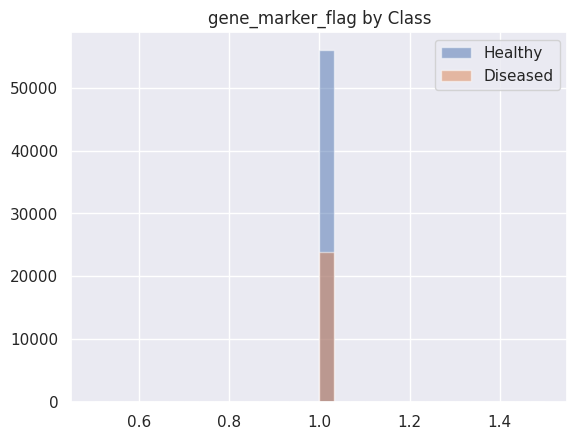

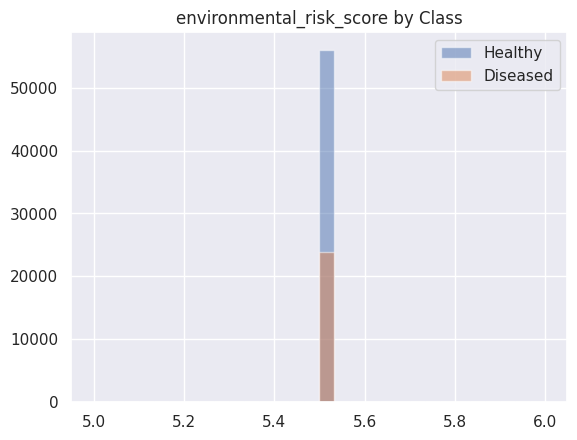

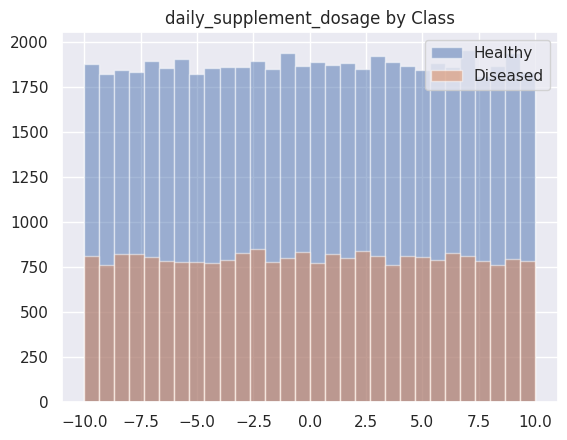

In [13]:
for col in X_train_df.columns[:50]:  # sample a few to start
    if np.issubdtype(X_train_df[col].dtype, np.number):
        plt.figure()
        plt.hist(X_train_df.loc[y_train==0, col], bins=30, alpha=0.5, label="Healthy")
        plt.hist(X_train_df.loc[y_train==1, col], bins=30, alpha=0.5, label="Diseased")
        plt.title(f"{col} by Class"); plt.legend(); plt.show()